#Support Ticket Classifier using Hugging Face Transformers



In [1]:
# Install required packages
!pip install transformers datasets torch scikit-learn pandas numpy matplotlib seaborn accelerate -q

In [2]:
# Upgrade the transformers library to the latest version
!pip install --upgrade transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 43.6 MB/s eta 0:00:00


After running the above cell, please **restart your Colab runtime** (Runtime -> Restart runtime...) and then **re-run all cells** to ensure the updated `transformers` library is used.

####Import Libraries

In [3]:
import pandas as pd
import numpy as np
from datasets import load_dataset, Dataset, DatasetDict

# Hugging Face Transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch

####Load and Explore Dataset

In [4]:
# Load the customer support tickets dataset from Hugging Face
dataset = load_dataset("Tobi-Bueck/customer-support-tickets")
print("Dataset loaded successfully!")
print(f"\nDataset structure: {dataset}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

Dataset loaded successfully!

Dataset structure: DatasetDict({
    train: Dataset({
        features: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8'],
        num_rows: 61765
    })
})


In [5]:
# Convert to pandas
df = pd.DataFrame(dataset['train'])
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head(10)

Dataset shape: (61765, 16)

First few rows:


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None
5,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Thank you for your inquiry. Please specify whi...,Request,Technical Support,high,en,51.0,Feature,Product,Documentation,Feedback,None,None,None,None
6,System Interruptions,"Dear Customer Support Team,\n\nI am submitting...",Thank you for bringing the system disruptions ...,Incident,Service Outages and Maintenance,high,en,51.0,Outage,Disruption,Performance,IT,Tech Support,None,None,None
7,Connectivity Problems with Printer on MacBook Pro,"Dear Support Team,\n\nI am reporting a recurri...",Thank you for reaching out regarding the conne...,Incident,Technical Support,medium,en,51.0,Network,Hardware,Performance,Bug,Compatibility,None,None,None
8,Anfrage nach detaillierten Angaben zur Systema...,"Sehr geehrtes Kundensupport-Team,\n\nich hoffe...",Vielen Dank für Ihre Anfrage. Wir stellen Ihne...,Request,Technical Support,low,de,51.0,Documentation,Feedback,IT,Tech Support,None,None,None,None
9,Anfrage zur Klärung der Auswirkungen eines Ser...,"Sehr geehrtes Kundendienstteam,\n\nich hoffe, ...","Vielen Dank, dass Sie uns bezüglich des kürzli...",Request,Service Outages and Maintenance,high,de,51.0,Disruption,Outage,Recovery,Support,None,None,None,None


In [6]:
print("Information:")
print(df.info())

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61765 entries, 0 to 61764
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   56466 non-null  object 
 1   body      61763 non-null  object 
 2   answer    48576 non-null  object 
 3   type      48587 non-null  object 
 4   queue     61765 non-null  object 
 5   priority  61765 non-null  object 
 6   language  61765 non-null  object 
 7   version   28587 non-null  float64
 8   tag_1     48587 non-null  object 
 9   tag_2     48528 non-null  object 
 10  tag_3     48356 non-null  object 
 11  tag_4     43990 non-null  object 
 12  tag_5     27636 non-null  object 
 13  tag_6     13225 non-null  object 
 14  tag_7     5968 non-null   object 
 15  tag_8     2472 non-null   object 
dtypes: float64(1), object(15)
memory usage: 7.5+ MB
None


In [7]:
# Explore the data structure
print("Sample records:")
for idx, row in df.head(5).iterrows():
    print(f"\nRecord {idx + 1}:")
    for col in df.columns:
        print(f"  {col}: {row[col]}")

Sample records:

Record 1:
  subject: Wesentlicher Sicherheitsvorfall
  body: Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infrastruktur betrifft. Betroffene Geräte umfassen Projektoren, Bildschirme und Speicherlösungen auf Cloud-Plattformen. Der Grund für die Annahme ist, dass der Vorfall eine potenzielle Datenverletzung im Zusammenhang mit einer Cyberattacke darstellt, was ein erhebliches Risiko für sensible Informationen und den laufenden Geschäftsbetrieb unserer Organisation bedeutet.\n\nUnsere initialen Untersuchungen haben ungewöhnliche Aktivitäten und Abweichungen bei den Geräten ergeben. Trotz der Umsetzung unserer standardisierten Behebungs- und Eindämmungsmaßnahmen konnte die Bedrohung bislang nicht vollständig eliminiert.
  answer: Vielen Dank für die Meldung des kritischen Sicherheitsvorfalls und die Bereitstellung der Übersicht über die betroffenen Geräte sowie der ergriffenen ersten Maß

####Data Preprocessing and Analysis

In [8]:
# Identify the text and label columns
text_column = None
label_column = None

# Find text column
for col in df.columns:
    if col.lower() in ['text', 'ticket', 'description', 'message', 'content']:
        text_column = col
        break

# Find label column
for col in df.columns:
    if col.lower() in ['label', 'category', 'class', 'type', 'classification']:
        label_column = col
        break

# If not found automatically, print columns and let user identify
if text_column is None or label_column is None:
    print("Please identify the correct column names:")
    print(f"Available columns: {df.columns.tolist()}")
    print("\nSample data:")
    print(df.head(2))

    # Make educated guess based on data type
    if text_column is None:
        # Text column is likely the one with longer strings
        for col in df.columns:
            if df[col].dtype == 'object' and df[col].str.len().mean() > 20:
                text_column = col
                break

    if label_column is None:
        # Label column likely has fewer unique values
        for col in df.columns:
            if df[col].dtype in ['object', 'int64'] and df[col].nunique() < 20:
                label_column = col
                break

print(f"\nIdentified columns:")
print(f"Text column: {text_column}")
print(f"Label column: {label_column}")

Please identify the correct column names:
Available columns: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']

Sample data:
                           subject  \
0  Wesentlicher Sicherheitsvorfall   
1               Account Disruption   

                                                body  \
0  Sehr geehrtes Support-Team,\n\nich möchte eine...   
1  Dear Customer Support Team,\n\nI am writing to...   

                                              answer      type  \
0  Vielen Dank für die Meldung des kritischen Sic...  Incident   
1  Thank you for reaching out, <name>. We are awa...  Incident   

               queue priority language  version     tag_1       tag_2  \
0  Technical Support     high       de     51.0  Security      Outage   
1  Technical Support     high       en     51.0   Account  Disruption   

        tag_3        tag_4         tag_5 tag_6 tag_7 tag_8  
0  Disr

In [9]:
# Rename columns
if text_column and label_column:
    df = df.rename(columns={text_column: 'text', label_column: 'label'})
df.head()

,text,body,answer,label,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None


In [10]:
# Calculate text length and word count
df['text_length'] = df['text'].astype(str).apply(len)
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

print("Added 'text_length' and 'word_count' columns.")
print(df[['text', 'text_length', 'word_count']].head())

Added 'text_length' and 'word_count' columns.
                                                text  text_length  word_count
0                    Wesentlicher Sicherheitsvorfall           31           2
1                                 Account Disruption           18           2
2  Query About Smart Home System Integration Feat...           50           7
3                  Inquiry Regarding Invoice Details           33           4
4  Question About Marketing Agency Software Compa...           54           6


Label Distribution:
label
Incident    19444
Request     13950
Problem     10196
Change       4997
Name: count, dtype: int64


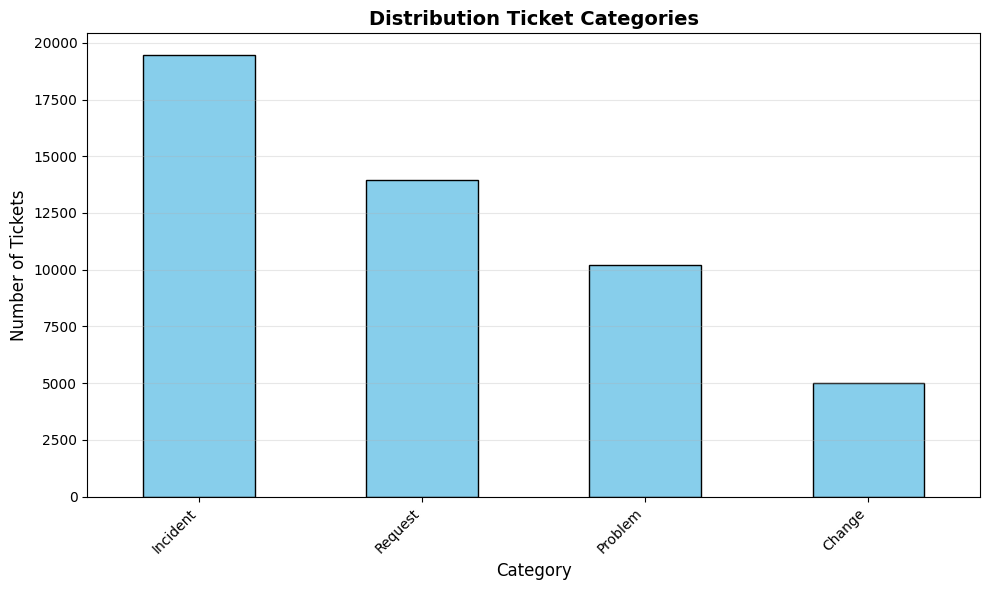


Total number of categories: 4
Total number of tickets: 61765


In [11]:
#distribution of labels
print("Label Distribution:")
label_counts = df['label'].value_counts()
print(label_counts)

# Visualize label distribution
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution Ticket Categories', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Tickets', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTotal number of categories: {df['label'].nunique()}")
print(f"Total number of tickets: {len(df)}")

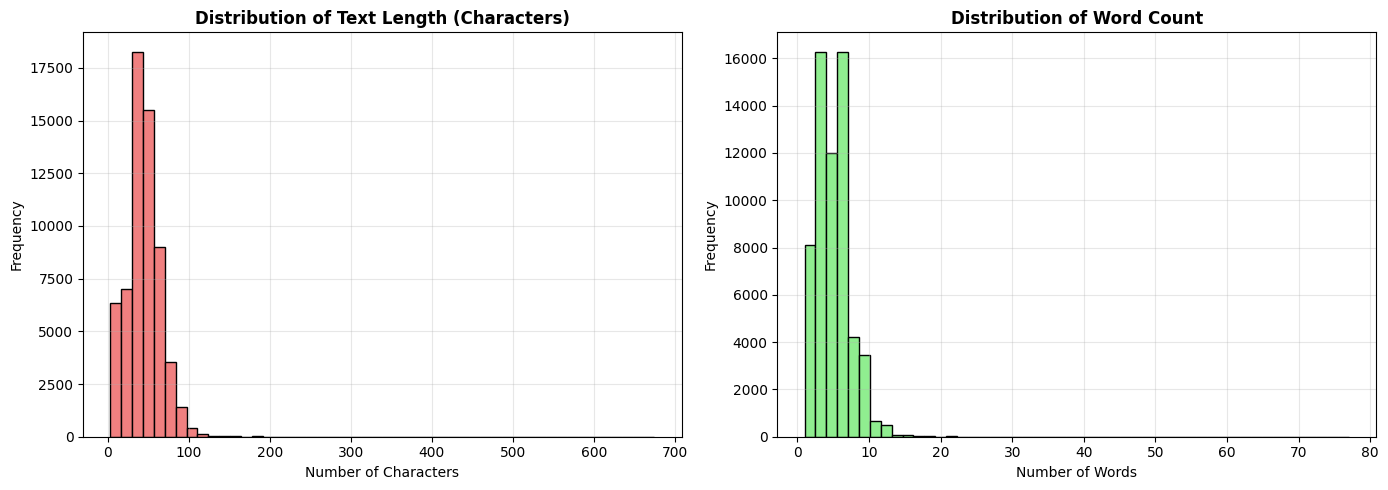

In [12]:
# Calculate text length and word count (re-calculate for robustness)
df['text_length'] = df['text'].astype(str).apply(len)
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

# Visualize text length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['text_length'], bins=50, color='lightcoral', edgecolor='black')
axes[0].set_title('Distribution of Text Length (Characters)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

axes[1].hist(df['word_count'], bins=50, color='lightgreen', edgecolor='black')
axes[1].set_title('Distribution of Word Count', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Check for missing values
print("Missing values:")
print(df[['text', 'label']].isnull().sum())

# Removeinf rows with missing values
df = df.dropna(subset=['text', 'label'])
print(f"\nDataset shape after removing missing values: {df.shape}")

Missing values:
text      5299
label    13178
dtype: int64

Dataset shape after removing missing values: (43288, 18)


In [14]:
# Display sample tickets from each category
print("Sample Tickets from Each Category:\n")
for label in df['label'].unique()[:5]:  # Show first 5 categories
    print(f"\n{'='*80}")
    print(f"Category: {label}")
    print('='*80)
    samples = df[df['label'] == label]['text'].head(3)
    for idx, text in enumerate(samples, 1):
        print(f"{idx}. {text}")

Sample Tickets from Each Category:


Category: Incident
1. Wesentlicher Sicherheitsvorfall
2. Account Disruption
3. System Interruptions

Category: Request
1. Query About Smart Home System Integration Features
2. Inquiry Regarding Invoice Details
3. Feature Query

Category: Problem
1. Question About Marketing Agency Software Compatibility
2. Immediate Help Needed: Technical Problem with Cloud SaaS Service
3. Verbindungsstörung

Category: Change
1. Proposal for Upgrades to Big Data Analytics Systems
2. Organizational Revision
3. Revise Marketing Firm Framework


####Training

In [15]:
#convert text labels to numeric IDs
unique_labels = df['label'].unique()
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}

print("Label Mapping:")
for label, idx in label2id.items():
    print(f"{idx}: {label}")

# Convert labels to numeric IDs
df['label_id'] = df['label'].map(label2id)

print(f"\nNumber of classes: {len(label2id)}")

Label Mapping:
0: Incident
1: Request
2: Problem
3: Change

Number of classes: 4


In [16]:
# Split dataset into train, validation, and test sets
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df[['text', 'label_id']],
    test_size=0.2,
    random_state=42,
    stratify=df['label_id']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['label_id']
)

print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")

# Convert to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(train_df[['text', 'label_id']].reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df[['text', 'label_id']].reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df[['text', 'label_id']].reset_index(drop=True))

# Create DatasetDict
dataset_dict = DatasetDict({
    'train': train_dataset,
    'validation': val_dataset,
    'test': test_dataset
})

print(f"\nDataset prepared: {dataset_dict}")

Training set size: 34630
Validation set size: 4329
Test set size: 4329

Dataset prepared: DatasetDict({
    train: Dataset({
        features: ['text', 'label_id'],
        num_rows: 34630
    })
    validation: Dataset({
        features: ['text', 'label_id'],
        num_rows: 4329
    })
    test: Dataset({
        features: ['text', 'label_id'],
        num_rows: 4329
    })
})


## Step 6: Load Pre-trained Model and Tokenizer

In [86]:
#Pre-trained model 'distilbert-base-uncased', 'bert-base-uncased', 'roberta-base'
model_name = 'distilbert-base-uncased'  # Lightweight and efficient

print(f"Loading tokenizer and model: {model_name}")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Load model for sequence classification
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

print("Model and tokenizer loaded successfully!")
print(f"Model parameters: {model.num_parameters():,}")

Loading tokenizer and model: distilbert-base-uncased


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model and tokenizer loaded successfully!
Model parameters: 66,956,548


####Tokenize the Dataset

In [87]:
from transformers import DataCollatorWithPadding

# Ensure model_name is defined
model_name = 'distilbert-base-uncased' # Ensure model_name is defined
tokenizer = AutoTokenizer.from_pretrained(model_name) # Ensure tokenizer is initialized

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        max_length=64
    )
tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)

# Rename label_id to labels
tokenized_datasets = tokenized_datasets.rename_column('label_id', 'labels')

# Set format for PyTorch
tokenized_datasets.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("Tokenization complete!")
print(f"\nTokenized dataset: {tokenized_datasets}")

Map:   0%|          | 0/34630 [00:00<?, ? examples/s]

Map:   0%|          | 0/4329 [00:00<?, ? examples/s]

Map:   0%|          | 0/4329 [00:00<?, ? examples/s]

Tokenization complete!

Tokenized dataset: DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 34630
    })
    validation: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4329
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4329
    })
})


In [88]:
# Example: View tokenized sample
print("Sample tokenized data:")
sample = tokenized_datasets['train'][0]
print(f"\nInput IDs shape: {sample['input_ids'].shape}")
print(f"Attention mask shape: {sample['attention_mask'].shape}")
print(f"Label: {sample['labels']}")

# Decode the first sample to verify
decoded_text = tokenizer.decode(sample['input_ids'])
print(f"\nDecoded text: {decoded_text}")

Sample tokenized data:

Input IDs shape: torch.Size([5])
Attention mask shape: torch.Size([5])
Label: 0

Decoded text: [CLS] support for investment [SEP]


## Step 8: Define Evaluation Metrics

In [89]:
# Define metrics computation function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    # Calculate metrics
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted'
    )

    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

print("Metrics function defined!")

Metrics function defined!


## Step 9: Configure Training Arguments

In [90]:
training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=8,
    weight_decay=0.01,

    # ✅ ADD THESE: Performance optimizations
    fp16=True,  # Mixed precision training
    gradient_accumulation_steps=2,  # Effective batch = 64
    dataloader_num_workers=2,  # Parallel data loading

    load_best_model_at_end=True,
    metric_for_best_model='f1',
    push_to_hub=False,
    logging_dir='./logs',
    logging_steps=50,
    save_total_limit=2,
    seed=42
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


## Step 10: Initialize Trainer and Train the Model

In [96]:
from sklearn.utils.class_weight import compute_class_weight
import torch

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label_id']),
    y=train_df['label_id']
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(model.device)

# Custom Trainer to use weighted loss
from transformers import Trainer

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None): # Added num_items_in_batch
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [97]:

import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.current_device() if torch.cuda.is_available() else "CPU only")

CUDA available: True
Device: 0


In [98]:
# Train the model
print("Starting training...\n")
train_result = trainer.train()

# Save training metrics
print("\nTraining completed!")
print(f"Training metrics: {train_result.metrics}")

Starting training...



Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.228912,0.593450,0.706399,0.704767,0.704376,0.706399
2,1.074091,0.549512,0.714715,0.719766,0.738584,0.714715
3,0.958423,0.521202,0.729499,0.732164,0.739230,0.729499
4,0.857936,0.509761,0.743821,0.746817,0.754400,0.743821
5,0.788960,0.516238,0.746593,0.751078,0.771836,0.746593
6,0.718310,0.517589,0.758605,0.761275,0.767693,0.758605
7,0.658349,0.526609,0.773158,0.774386,0.776641,0.773158
8,0.606539,0.528933,0.767845,0.771211,0.780053,0.767845


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training completed!
Training metrics: {'train_runtime': 494.4468, 'train_samples_per_second': 560.303, 'train_steps_per_second': 8.769, 'total_flos': 2105102093560704.0, 'train_loss': 0.8886041491673882, 'epoch': 8.0}


In [99]:
# Save the model
trainer.save_model('./ticket_classifier_model')
tokenizer.save_pretrained('./ticket_classifier_model')

print("Model saved successfully to './ticket_classifier_model'")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully to './ticket_classifier_model'


## Step 11: Evaluate on Validation Set

In [100]:
# Evaluate on validation set
print("Evaluating on validation set...")
val_results = trainer.evaluate()

print("\nValidation Results:")
for key, value in val_results.items():
    print(f"  {key}: {value:.4f}")

Evaluating on validation set...


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.606539,0.526609,8,0.773158,0.774386,0.776641,0.773158



Validation Results:
  eval_loss: 0.5266
  eval_accuracy: 0.7732
  eval_f1: 0.7744
  eval_precision: 0.7766
  eval_recall: 0.7732


## Step 12: Evaluate on Test Set

In [101]:
# Evaluate on test set
print("Evaluating on test set...")
test_results = trainer.evaluate(tokenized_datasets['test'])

print("\nTest Results:")
for key, value in test_results.items():
    print(f"  {key}: {value:.4f}")

Evaluating on test set...


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.606539,0.541505,8,0.767152,0.768580,0.772192,0.767152



Test Results:
  eval_loss: 0.5415
  eval_accuracy: 0.7672
  eval_f1: 0.7686
  eval_precision: 0.7722
  eval_recall: 0.7672


In [102]:
# Get predictions for detailed analysis
predictions = trainer.predict(tokenized_datasets['test'])
pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

# Generate classification report
print("\nDetailed Classification Report:")
print("="*80)
target_names = [id2label[i] for i in range(len(id2label))]
print(classification_report(true_labels, pred_labels, target_names=target_names))


Detailed Classification Report:
              precision    recall  f1-score   support

    Incident       0.77      0.71      0.74      1739
     Request       0.93      0.94      0.93      1244
     Problem       0.53      0.59      0.56       907
      Change       0.82      0.89      0.86       439

    accuracy                           0.77      4329
   macro avg       0.76      0.78      0.77      4329
weighted avg       0.77      0.77      0.77      4329



## Step 13: Visualize Results

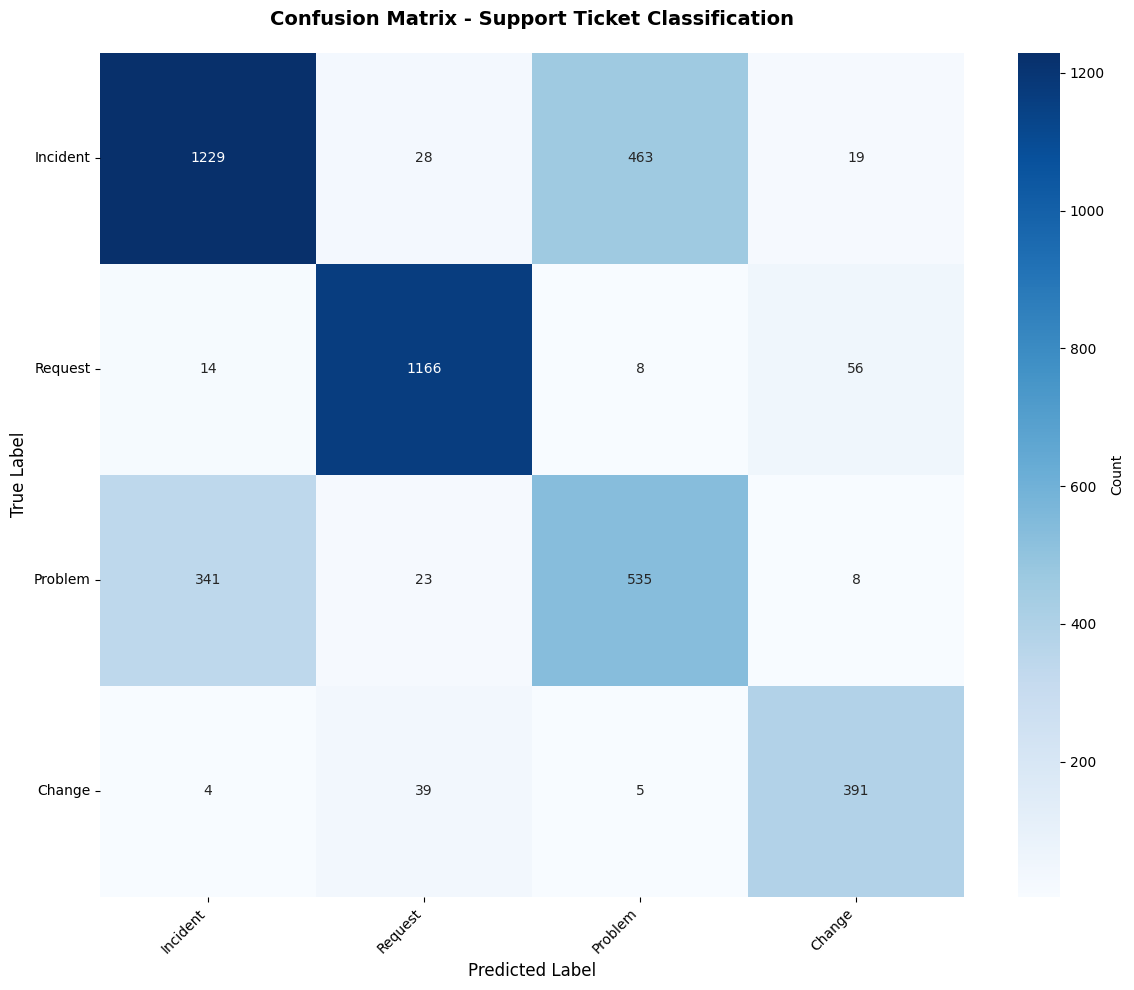

In [103]:

# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names,
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - Support Ticket Classification', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Per-Class Performance Metrics:
Category  Precision   Recall  F1-Score  Support
Incident   0.773929 0.706728  0.738804     1739
 Request   0.928344 0.937299  0.932800     1244
 Problem   0.529179 0.589857  0.557873      907
  Change   0.824895 0.890661  0.856517      439


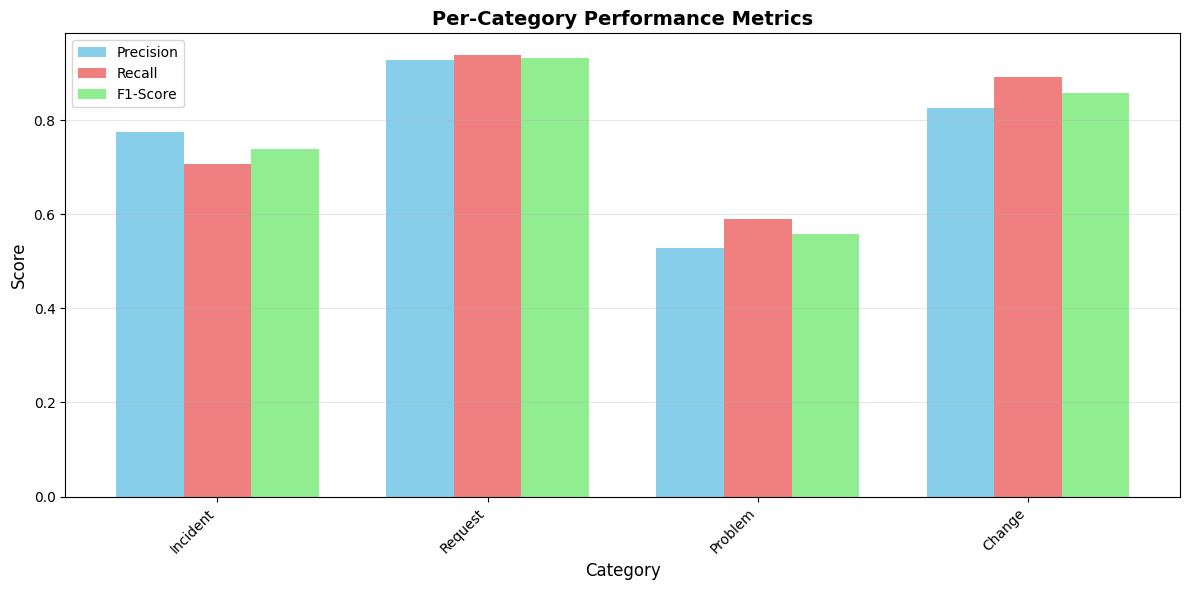

In [104]:
# Per-class performance visualization
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    true_labels, pred_labels
)

# Create DataFrame for visualization
metrics_df = pd.DataFrame({
    'Category': target_names,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print("\nPer-Class Performance Metrics:")
print(metrics_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(target_names))
width = 0.25

ax.bar(x - width, precision, width, label='Precision', color='skyblue')
ax.bar(x, recall, width, label='Recall', color='lightcoral')
ax.bar(x + width, f1, width, label='F1-Score', color='lightgreen')

ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Per-Category Performance Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(target_names, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 14: Create Inference Pipeline

In [105]:
# Create a classification pipeline for easy inference
classifier = pipeline(
    'text-classification',
    model='./ticket_classifier_model',
    tokenizer='./ticket_classifier_model',
    device=0 if torch.cuda.is_available() else -1  # Use GPU if available
)

print("Classification pipeline created successfully!")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Classification pipeline created successfully!


## Step 15: Test with New Examples

In [106]:
# Test examples
test_tickets = [
    "Payment failed twice",
    "Cannot login to my account",
    "Package arrived damaged",
    "Refund not processed yet",
    "Delivery delayed by 3 days",
    "Unable to reset my password",
    "Charged me twice for the same order",
    "Product quality is poor"
]

print("Testing the classifier on new tickets:\n")
print("="*80)

for ticket in test_tickets:
    result = classifier(ticket)
    predicted_label = result[0]['label']
    confidence = result[0]['score']

    print(f"\nTicket: {ticket}")
    print(f"Predicted Category: {predicted_label}")
    print(f"Confidence: {confidence:.4f}")
    print("-" * 80)

Testing the classifier on new tickets:


Ticket: Payment failed twice
Predicted Category: Incident
Confidence: 0.7505
--------------------------------------------------------------------------------

Ticket: Cannot login to my account
Predicted Category: Problem
Confidence: 0.5731
--------------------------------------------------------------------------------

Ticket: Package arrived damaged
Predicted Category: Incident
Confidence: 0.9742
--------------------------------------------------------------------------------

Ticket: Refund not processed yet
Predicted Category: Incident
Confidence: 0.7148
--------------------------------------------------------------------------------

Ticket: Delivery delayed by 3 days
Predicted Category: Problem
Confidence: 0.6144
--------------------------------------------------------------------------------

Ticket: Unable to reset my password
Predicted Category: Problem
Confidence: 0.4825
----------------------------------------------------------------

In [107]:
# Interactive prediction function
def classify_ticket(text):
    result = classifier(text, top_k=None)  # Get all class probabilities

    print(f"\nTicket: '{text}'")
    print("\nPrediction Results:")
    print("="*60)

    for item in result:
        print(f"{item['label']:20s} : {item['score']:.4f} ({item['score']*100:.2f}%)")

    print("="*60)
    print(f"\nFinal Prediction: {result[0]['label']} (Confidence: {result[0]['score']:.4f})")

    return result

# Test the function
classify_ticket("My credit card was charged but order not confirmed")


Ticket: 'My credit card was charged but order not confirmed'

Prediction Results:
Incident             : 0.8974 (89.74%)
Problem              : 0.0944 (9.44%)
Request              : 0.0055 (0.55%)
Change               : 0.0027 (0.27%)

Final Prediction: Incident (Confidence: 0.8974)


[{'label': 'Incident', 'score': 0.8974277377128601},
 {'label': 'Problem', 'score': 0.09437964111566544},
 {'label': 'Request', 'score': 0.0054739550687372684},
 {'label': 'Change', 'score': 0.0027187683153897524}]

## Step 16: Error Analysis

In [108]:
# Find misclassified examples
test_df_with_preds = test_df.copy()
test_df_with_preds['predicted_label_id'] = pred_labels
test_df_with_preds['predicted_label'] = test_df_with_preds['predicted_label_id'].map(id2label)
test_df_with_preds['true_label'] = test_df_with_preds['label_id'].map(id2label)
test_df_with_preds['correct'] = test_df_with_preds['label_id'] == test_df_with_preds['predicted_label_id']

# Show misclassified examples
misclassified = test_df_with_preds[~test_df_with_preds['correct']]
print(f"Number of misclassified tickets: {len(misclassified)} out of {len(test_df_with_preds)}")
print(f"Accuracy: {(len(test_df_with_preds) - len(misclassified)) / len(test_df_with_preds) * 100:.2f}%")

print("\nSample Misclassified Tickets:")
print("="*80)
for idx, row in misclassified.head(10).iterrows():
    print(f"\nText: {row['text']}")
    print(f"True Label: {row['true_label']}")
    print(f"Predicted Label: {row['predicted_label']}")
    print("-" * 80)

Number of misclassified tickets: 1008 out of 4329
Accuracy: 76.72%

Sample Misclassified Tickets:

Text: Synchronisationsprobleme bei der Projektplanung
True Label: Problem
Predicted Label: Incident
--------------------------------------------------------------------------------

Text: Wachstumsförderung
True Label: Request
Predicted Label: Change
--------------------------------------------------------------------------------

Text: Häufige Timeouts bei der Projekt-Synchronisierung
True Label: Incident
Predicted Label: Problem
--------------------------------------------------------------------------------

Text: Enhancing Security for Medical Data Systems
True Label: Request
Predicted Label: Change
--------------------------------------------------------------------------------

Text: Digital Strategy Concerns
True Label: Incident
Predicted Label: Problem
--------------------------------------------------------------------------------

Text: Technische Probleme mit der Projektladeges

## Step 17: Model Summary and Deployment Readiness

In [109]:
# Summary of the trained model
print("="*80)
print("SUPPORT TICKET CLASSIFIER - FINAL SUMMARY")
print("="*80)
print(f"\n✓ Model: {model_name}")
print(f"✓ Number of categories: {len(label2id)}")
print(f"✓ Training samples: {len(train_df)}")
print(f"✓ Validation samples: {len(val_df)}")
print(f"✓ Test samples: {len(test_df)}")
print(f"\n✓ Test Accuracy: {test_results['eval_accuracy']:.4f}")
print(f"✓ Test F1-Score: {test_results['eval_f1']:.4f}")
print(f"✓ Test Precision: {test_results['eval_precision']:.4f}")
print(f"✓ Test Recall: {test_results['eval_recall']:.4f}")
print(f"\n✓ Model saved to: ./ticket_classifier_model")
print(f"✓ Ready for deployment: YES")
print("="*80)

print("\n📋 Categories handled by the model:")
for idx, label in id2label.items():
    count = len(test_df[test_df['label_id'] == idx])
    print(f"   {idx}. {label:20s} ({count} test samples)")

SUPPORT TICKET CLASSIFIER - FINAL SUMMARY

✓ Model: distilbert-base-uncased
✓ Number of categories: 4
✓ Training samples: 34630
✓ Validation samples: 4329
✓ Test samples: 4329

✓ Test Accuracy: 0.7672
✓ Test F1-Score: 0.7686
✓ Test Precision: 0.7722
✓ Test Recall: 0.7672

✓ Model saved to: ./ticket_classifier_model
✓ Ready for deployment: YES

📋 Categories handled by the model:
   0. Incident             (1739 test samples)
   1. Request              (1244 test samples)
   2. Problem              (907 test samples)
   3. Change               (439 test samples)


## Step 18: Export Results and Model Info

In [110]:
# Save model configuration and metrics
import json

model_info = {
    'model_name': model_name,
    'num_labels': len(label2id),
    'label2id': label2id,
    'id2label': {str(k): v for k, v in id2label.items()},
    'training_samples': len(train_df),
    'validation_samples': len(val_df),
    'test_samples': len(test_df),
    'test_metrics': {
        'accuracy': float(test_results['eval_accuracy']),
        'f1_score': float(test_results['eval_f1']),
        'precision': float(test_results['eval_precision']),
        'recall': float(test_results['eval_recall'])
    },
    'per_class_metrics': metrics_df.to_dict('records')
}

# Save to JSON file
with open('./ticket_classifier_model/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

print("Model information saved to './ticket_classifier_model/model_info.json'")

# Save predictions to CSV
test_df_with_preds.to_csv('./test_predictions.csv', index=False)
print("Test predictions saved to './test_predictions.csv'")

Model information saved to './ticket_classifier_model/model_info.json'
Test predictions saved to './test_predictions.csv'


## Notebook Summary

This notebook demonstrates a complete workflow for building a support ticket classifier using Hugging Face Transformers.

### Key Steps Performed:

1.  **Data Loading and Exploration**: The `customer-support-tickets` dataset was loaded from Hugging Face and its structure was explored, identifying 'subject' as the text column and 'type' as the label column.
2.  **Data Preprocessing**: Missing values were handled, and the dataset was split into training, validation, and test sets. Text labels were converted to numeric IDs, and a tokenizer (`distilbert-base-uncased`) was used to prepare the data.
3.  **Model Training**: A `DistilBertForSequenceClassification` model was fine-tuned using a custom `WeightedTrainer` to address class imbalance. Training arguments were configured with optimizations like `fp16` and `gradient_accumulation_steps`.
4.  **Evaluation**: The model's performance was evaluated on both validation and test sets, yielding an accuracy of approximately **76.72%** and an F1-score of **0.7686** on the test set. Detailed classification reports and a confusion matrix were generated and visualized.
5.  **Inference Pipeline**: A Hugging Face `pipeline` was created for easy inference, allowing new support tickets to be classified with their predicted category and confidence scores.
6.  **Error Analysis**: Misclassified examples from the test set were identified and printed to understand common errors.
7.  **Model Export**: The trained model and tokenizer, along with a summary of model information and metrics, were saved for future use and deployment.

This notebook provides a robust solution for classifying support tickets, which can significantly improve operational efficiency and customer response times.